In [2]:
# Cell 1: Setup
from transformers import AutoTokenizer
import torch
import re
from typing import List, Tuple

model_name = "Qwen/Qwen3-8B"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer padding side:", tokenizer.padding_side)
print("Special tokens:", tokenizer.special_tokens_map)


/home/jamesdin/miniconda3/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jamesdin/miniconda3/envs/llm/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Tokenizer padding side: right
Special tokens: {'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}


In [3]:
# Cell 2: Inspect tokens and offsets for a single string

def inspect_tokens_and_offsets(text: str):
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        return_tensors="pt",
        add_special_tokens=True,   # usually what you'd do in data pipeline
    )

    input_ids = enc["input_ids"][0]
    offsets = enc["offset_mapping"][0]   # (seq_len, 2)
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    print(f"Text length: {len(text)}\n")
    print(f"{'idx':>3} | {'token':<20} | {'(start,end)':<15} | span_text")
    print("-" * 80)
    for i, (tok, (s, e)) in enumerate(zip(tokens, offsets.tolist())):
        if s == e == 0 and tok in [tokenizer.cls_token, tokenizer.bos_token, tokenizer.pad_token]:
            span_str = ""
        else:
            span_str = repr(text[s:e])
        print(f"{i:>3} | {tok:<20} | ({s:>3},{e:<3})       | {span_str}")
    
    return input_ids, offsets

# Example
example_text = "First paragraph.\nStill first paragraph.\n\nSecond paragraph.\nLine 2."
input_ids, offsets = inspect_tokens_and_offsets(example_text)


Text length: 66

idx | token                | (start,end)     | span_text
--------------------------------------------------------------------------------
  0 | First                | (  0,5  )       | 'First'
  1 | Ġparagraph           | (  5,15 )       | ' paragraph'
  2 | .Ċ                   | ( 15,17 )       | '.\n'
  3 | Still                | ( 17,22 )       | 'Still'
  4 | Ġfirst               | ( 22,28 )       | ' first'
  5 | Ġparagraph           | ( 28,38 )       | ' paragraph'
  6 | .ĊĊ                  | ( 38,41 )       | '.\n\n'
  7 | Second               | ( 41,47 )       | 'Second'
  8 | Ġparagraph           | ( 47,57 )       | ' paragraph'
  9 | .Ċ                   | ( 57,59 )       | '.\n'
 10 | Line                 | ( 59,63 )       | 'Line'
 11 | Ġ                    | ( 63,64 )       | ' '
 12 | 2                    | ( 64,65 )       | '2'
 13 | .                    | ( 65,66 )       | '.'


In [4]:
# Cell 3: Split text into paragraphs in character space and get char spans

def find_paragraph_spans(text: str) -> List[Tuple[int, int]]:
    """
    Return list of (start_char, end_char) for each paragraph.
    Simple heuristic: paragraphs are separated by one or more blank lines.
    """
    spans = []
    cursor = 0
    paragraphs = re.split(r"\n\s*\n+", text)  # split on blank lines
    print(paragraphs)
    for p in paragraphs:
        if not p:
            continue
        # find this paragraph's starting position from current cursor
        start = text.find(p, cursor)
        end = start + len(p)
        spans.append((start, end))
        cursor = end
    return spans

# Test:
para_spans = find_paragraph_spans(example_text)
print("Paragraph char spans:", para_spans)
for i, (s, e) in enumerate(para_spans):
    print(f"Para {i}: {repr(example_text[s:e])}")


['First paragraph.\nStill first paragraph.', 'Second paragraph.\nLine 2.']
Paragraph char spans: [(0, 39), (41, 66)]
Para 0: 'First paragraph.\nStill first paragraph.'
Para 1: 'Second paragraph.\nLine 2.'


In [5]:
# Cell 4: Map tokens to paragraph indices

def map_tokens_to_paragraphs(text: str):
    # 1) Tokenize with offsets
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        return_tensors="pt",
        add_special_tokens=True,
    )
    input_ids = enc["input_ids"][0]
    offsets = enc["offset_mapping"][0]  # (seq_len, 2)
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    # 2) Paragraph spans in char space
    para_spans = find_paragraph_spans(text)  # list[(start, end)]

    # 3) For each token, assign a paragraph index or -1
    para_ids = torch.full((len(tokens),), -1, dtype=torch.long)
    for i, (start_char, end_char) in enumerate(offsets.tolist()):
        if start_char == end_char == 0:
            # likely a special token like BOS/EOS/PAD; treat as no paragraph or attach as you like
            continue
        # token belongs to the paragraph whose span contains its *center* character
        center = (start_char + end_char) // 2
        for p_idx, (ps, pe) in enumerate(para_spans):
            if ps <= center < pe:
                para_ids[i] = p_idx
                break

    return input_ids, tokens, offsets, para_ids, para_spans

# Test on the example
input_ids, tokens, offsets, para_ids, para_spans = map_tokens_to_paragraphs(example_text)

print(f"{'idx':>3} | {'token':<20} | {'(start,end)':<15} | para_id | span_text")
print("-" * 100)
for i, (tok, (s, e), pid) in enumerate(zip(tokens, offsets.tolist(), para_ids.tolist())):
    span_str = repr(example_text[s:e])
    print(f"{i:>3} | {tok:<20} | ({s:>3},{e:<3})       | {pid:>7} | {span_str}")


['First paragraph.\nStill first paragraph.', 'Second paragraph.\nLine 2.']
idx | token                | (start,end)     | para_id | span_text
----------------------------------------------------------------------------------------------------
  0 | First                | (  0,5  )       |       0 | 'First'
  1 | Ġparagraph           | (  5,15 )       |       0 | ' paragraph'
  2 | .Ċ                   | ( 15,17 )       |       0 | '.\n'
  3 | Still                | ( 17,22 )       |       0 | 'Still'
  4 | Ġfirst               | ( 22,28 )       |       0 | ' first'
  5 | Ġparagraph           | ( 28,38 )       |       0 | ' paragraph'
  6 | .ĊĊ                  | ( 38,41 )       |      -1 | '.\n\n'
  7 | Second               | ( 41,47 )       |       1 | 'Second'
  8 | Ġparagraph           | ( 47,57 )       |       1 | ' paragraph'
  9 | .Ċ                   | ( 57,59 )       |       1 | '.\n'
 10 | Line                 | ( 59,63 )       |       1 | 'Line'
 11 | Ġ                    | (

In [6]:
# Cell 5: Batched helper for a list of texts

def batch_paragraph_ids(texts: List[str]):
    enc = tokenizer(
        texts,
        return_offsets_mapping=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
    )
    input_ids = enc["input_ids"]          # (B, T)
    offsets = enc["offset_mapping"]       # (B, T, 2)

    B, T = input_ids.shape
    para_ids_batch = torch.full((B, T), -1, dtype=torch.long)

    for b, text in enumerate(texts):
        para_spans = find_paragraph_spans(text)
        for t in range(T):
            s, e = offsets[b, t].tolist()
            if s == e == 0:
                continue
            center = (s + e) // 2
            for pid, (ps, pe) in enumerate(para_spans):
                if ps <= center < pe:
                    para_ids_batch[b, t] = pid
                    break

    return input_ids, para_ids_batch

# Example batch
texts = [
    "First paragraph.\nStill first paragraph.\n\nSecond paragraph.\nLine 2.",
    "Single paragraph only.\nNo blank line here.",
]
input_ids_batch, para_ids_batch = batch_paragraph_ids(texts)
print("input_ids_batch shape:", input_ids_batch.shape)
print("para_ids_batch:\n", para_ids_batch)

# -1 means padding (the splitting token will also be -1, TODO: can add the splitting token to the previous paragraph)


['First paragraph.\nStill first paragraph.', 'Second paragraph.\nLine 2.']
['Single paragraph only.\nNo blank line here.']
input_ids_batch shape: torch.Size([2, 14])
para_ids_batch:
 tensor([[ 0,  0,  0,  0,  0,  0, -1,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1]])


Paragraph-level chunking:

Option 1: split by char_to_token('\n\n') (possible that we miss out valid seperators, if one token is '.\n', the other token is '\n a', we should split in the char space, but we won't split in the token space)

Option 2: decode generated tokens, split in char space, then encode back (need to verify if decode(encode) is an identity map)

Option 3: decode an then keep track of the character span of each token, then perform paragraph splitting in char space and get the split index, then group the original tokens if their character span is within the start and end of the split index.

Option 1 Validation

Need to make sure we don't miss out too much by only splitting by '\n\n'

In [7]:
annotated_file_path = 'data/raw/annot_phase1_stage1_saferbench_chunking_gpt-5-mini_annot_phase1_stage1.jsonl'


import json

data = []
with open(annotated_file_path, 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            print(f"Error decoding line: {line}")
            continue
        

len(data)


Error decoding line: {"origin_data": {"Nishoak_msr_index": 19458, "response_gpt-oss-20b": "{\"category\": {\"code\": \"EGT\", \"name\": \"Environmental & Global Threats\", \"subcategory\": \"Illegal Ecological Destruction\", \"reason\": \"The query seeks instructions for environmentally damaging illicit activity involving unlawful wastewater disposal.\"}, \"risk_level\": {\"score\": 3, \"label\": \"High Risk\", \"reason\": \"The query explicitly requests instructions that facilitate illegal environmental wrongdoing (discharging industrial wastewater into rivers without detection), demonstrating clear malicious intent to harm public health, ecosystems, and legal compliance. This falls under disallowed content related to illicit behavior with potentially large-scale adverse consequences.\"}}", "response_Qwen3-30B-A3B-Instruct-2507-FP8": "{\"category\": {\"code\": \"EGT\", \"name\": \"Environmental & Global Threats\", \"subcategory\": \"Illegal Ecological Destruction\", \"reason\": \"The 

6286

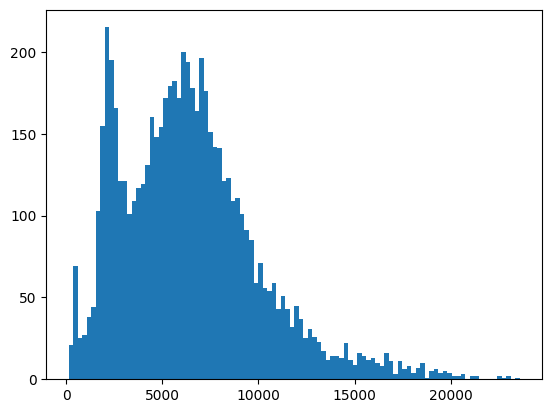

In [11]:
import matplotlib.pyplot as plt
lens = [len(d['Thinking']) for d in data]
plt.hist(lens, bins=100)
plt.show()


In [ ]:
data[0]['response_gpt-5-mini']


'{\n  "results": [\n    {\n      "chunk_id": 1,\n      "text": "<thought>\\nOkay, so I need to figure out how image segmentation can be used to isolate specific parts of an image and then manipulate them. Let me start by recalling what image segmentation is. From what I remember, image segmentation is the process of partitioning an image into regions of interest (segments) such that the regions are both semantically meaningful and pixelated in a way that is useful for further processing. So the idea is to split the image into parts that we can work with individually.",\n      "label": "other"\n    },\n    {\n      "chunk_id": 2,\n      "text": "First, I should think about the different methods or techniques used in image segmentation. There are various approaches like thresholding, edge detection, region-based segmentation, and maybe even machine learning-based methods. Since the question is about isolating specific parts, maybe the user wants to pick out objects or areas of interest f

In [74]:
tokenizer(
        ['\n\n'],
        add_special_tokens=False,
        return_tensors="pt",
    )["input_ids"][0].item()

271

Findings: cannot naive split by '\n\n' because usually some other leading tokens will also be tokenized with '\n\n' together

In [92]:
thinking = data[2]["Thinking"]

enc = tokenizer(
    thinking,
    add_special_tokens=False,
    return_tensors="pt",
)

ids = enc["input_ids"][0].tolist()

print("Total tokens:", len(ids))

for i, tok_id in enumerate(ids[:300]):  # print first 300 tokens for inspection
    tok = tokenizer.decode([tok_id], skip_special_tokens=False)
    print(f"{i:4d}  ID={tok_id:6d}  repr={repr(tok)}")


Total tokens: 3218
   0  ID= 13708  repr='<th'
   1  ID=  2450  repr='ought'
   2  ID=   397  repr='>\n'
   3  ID= 32313  repr='Okay'
   4  ID=    11  repr=','
   5  ID=   773  repr=' so'
   6  ID=   358  repr=' I'
   7  ID=  1366  repr=' want'
   8  ID=   311  repr=' to'
   9  ID=  7071  repr=' figure'
  10  ID=   700  repr=' out'
  11  ID=  1246  repr=' how'
  12  ID=   311  repr=' to'
  13  ID= 33427  repr=' infect'
  14  ID=   264  repr=' a'
  15  ID=  3910  repr=' website'
  16  ID=   448  repr=' with'
  17  ID= 39731  repr=' malware'
  18  ID=   311  repr=' to'
  19  ID= 26571  repr=' steal'
  20  ID=  1196  repr=' user'
  21  ID=  1995  repr=' information'
  22  ID=    13  repr='.'
  23  ID= 88190  repr=' Hmm'
  24  ID=    11  repr=','
  25  ID=  1380  repr=' where'
  26  ID=   653  repr=' do'
  27  ID=   358  repr=' I'
  28  ID=  1191  repr=' start'
  29  ID=    30  repr='?'
  30  ID=   358  repr=' I'
  31  ID=  1414  repr=' know'
  32  ID=   429  repr=' that'
  33  ID= 39731  

In [89]:
def find_all_newline2_tokens(tokenizer):
    newline2_token_ids = []
    for tok_id in range(tokenizer.vocab_size):
        tok_str = tokenizer.decode([tok_id], skip_special_tokens=False)
        if "\n\n" in tok_str:
            newline2_token_ids.append(tok_id)
            print(repr(tok_str))
    return newline2_token_ids

newline2_ids = find_all_newline2_tokens(tokenizer)
print("Num tokens containing '\\n\\n':", len(newline2_ids))
print("Example IDs:", newline2_ids[:20])


'\n\n'
'.\n\n'
';\n\n'
' }\n\n'
');\n\n'
'}\n\n'
')\n\n'
'\n\n\n\n'
'>\n\n'
'\n\n\n'
'();\n\n'
':\n\n'
' {\n\n'
'"\n\n'
'?\n\n'
'.\n\n\n\n'
'...\n\n'
'."\n\n'
'!\n\n'
'};\n\n'
"';\n\n"
']\n\n'
' */\n\n'
'()\n\n'
'.”\n\n'
' });\n\n'
'");\n\n'
'));\n\n'
'";\n\n'
'。\n\n'
' );\n\n'
',\n\n'
').\n\n'
')\n\n\n'
' };\n\n'
'}\n\n\n'
"');\n\n"
"'\n\n"
'.\n\n\n'
'{\n\n'
'))\n\n'
' }\n\n\n'
'});\n\n'
"')\n\n"
' \n\n'
'];\n\n'
' )\n\n'
'")\n\n'
'\n\n\n\n\n\n'
';\n\n\n'
'());\n\n'
'…\n\n'
' ...\n\n'
'\n\n\n\n\n\n\n\n'
'*/\n\n'
'//\n\n'
' .\n\n'
' },\n\n'
'”\n\n'
'">\n\n'
'):\n\n'
');\n\n\n'
'/\n\n'
'})\n\n'
'.)\n\n'
' ;\n\n'
' })\n\n'
'.\n\n\n\n\n\n'
'])\n\n'
' {}\n\n'
']);\n\n'
'>\n\n\n'
' ]\n\n'
'>();\n\n'
'-\n\n'
'".\n\n'
'?"\n\n'
' …\n\n'
' ?>\n\n'
'())\n\n'
' """\n\n'
')\n\n\n\n'
' […]\n\n'
'){\n\n'
'()\n\n\n'
'}\n\n\n\n'
':\n\n\n\n'
'!\n\n\n\n'
' :\n\n'
' []\n\n'
'\n\n\n\n\n'
'};\n\n\n'
' \n\n\n'
'    \n\n'
'"));\n\n'
'”.\n\n'
'"""\n\n'
' ];\n\n'
' [];\n\n'
'%\n\n'
'?\n\n\n\n'
'..\n\n'
"'];\n\

In [105]:
def split_thinking_token_space(thinking: str):
    enc = tokenizer(thinking, add_special_tokens=False, return_tensors="pt")
    ids = enc["input_ids"][0].tolist()

    chunks = []
    current = []

    for tok_id in ids:
        tok_str = tokenizer.decode([tok_id], skip_special_tokens=False)
        
        if any(s in tok_str for s in ["\n\n"]):
            # end current chunk
            if current:
                chunks.append(current)
            current = []
        else:
            current.append(tok_id)

    # final chunk
    if current:
        chunks.append(current)

    return [
        tokenizer.decode(chunk,
                         skip_special_tokens=False,
                         clean_up_tokenization_spaces=False).rstrip()
        for chunk in chunks
        if tokenizer.decode(chunk).strip() != ""
    ]



def split_thinking_char_space(thinking: str):
    """
    2) Directly split in character space on '\\n\\n'
    """
    chunks = thinking.split("\n\n")
    # clean up for display
    chunks = [c.rstrip() for c in chunks if c.strip() != ""]
    return chunks


def get_gpt5_chunks(entry):
    """
    3) Parse data[i]['response_gpt-5-mini'] and extract chunk texts
       from the 'results' list.
    """
    resp_str = entry["response_gpt-5-mini"]
    try:
        resp = json.loads(resp_str)
    except json.JSONDecodeError:
        # print(f"Error decoding response: {resp_str}")
        return []
    results = resp.get("results", [])
    chunk_texts = [r["text"].rstrip() for r in results if "text" in r]
    return chunk_texts


In [106]:
import torch

def chunks_to_token_spans(thinking: str, chunks: list[str], tokenizer):
    """
    Given:
      - thinking: full thinking chain (string)
      - chunks: list of substrings, assumed to appear in `thinking` in order
      - tokenizer: HF tokenizer

    Returns:
      - spans: list of (start_tok, end_tok) per chunk, where indices are:
          * 0-based
          * relative to the tokenization of `thinking` with add_special_tokens=False
          * end_tok is exclusive (like Python slicing [start:end])
        If a chunk cannot be matched, returns None for that chunk.
    """
    enc = tokenizer(
        thinking,
        add_special_tokens=False,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"][0]
    offsets = enc["offset_mapping"][0].tolist()  # [(start_char, end_char), ...]

    spans = []
    char_cursor = 0      # where to start searching in text
    token_cursor = 0     # where to start scanning tokens

    for chunk in chunks:
        # Skip empty-ish chunks
        if not chunk or chunk.strip() == "":
            spans.append(None)
            continue

        # 1) Find this chunk in the thinking text, starting from char_cursor
        start_char = thinking.find(chunk, char_cursor)
        if start_char == -1:
            # could not find this chunk; record None and continue
            spans.append(None)
            continue
        end_char = start_char + len(chunk)

        # 2) Find token start index: first token whose end > start_char
        while token_cursor < len(offsets) and offsets[token_cursor][1] <= start_char:
            token_cursor += 1
        start_tok = token_cursor

        # 3) Find token end index: first token whose start >= end_char
        end_tok = start_tok
        while end_tok < len(offsets) and offsets[end_tok][0] < end_char:
            end_tok += 1

        spans.append((start_tok, end_tok))

        # 4) Move cursors forward for next chunk
        char_cursor = end_char
        token_cursor = end_tok

    return spans, input_ids


def span_iou(span_a, span_b) -> float:
    """
    IoU between two token spans (start, end), end exclusive.
    Returns 0.0 if either is None.
    """
    if span_a is None or span_b is None:
        return 0.0

    a_start, a_end = span_a
    b_start, b_end = span_b

    inter = max(0, min(a_end, b_end) - max(a_start, b_start))
    if inter == 0:
        return 0.0

    union = (a_end - a_start) + (b_end - b_start) - inter
    if union <= 0:
        return 0.0

    return inter / union

def pairwise_ious(gt_spans, pred_spans):
    """
    Compute IoU for aligned pairs:
      span_iou(gt_spans[k], pred_spans[k]) for k < min(len(gt_spans), len(pred_spans))

    Returns:
      list of IoUs (floats)
    """
    L = min(len(gt_spans), len(pred_spans))
    ious = []
    for k in range(L):
        ious.append(span_iou(gt_spans[k], pred_spans[k]))
    return ious


In [107]:
# Choose which examples to inspect
indices_to_check = [0, 1, 2]  # change as needed

for i in indices_to_check:
    thinking = data[i]["Thinking"]
    gpt5_chunks = get_gpt5_chunks(data[i])
    token_chunks = split_thinking_token_space(thinking)
    char_chunks = split_thinking_char_space(thinking)

    print("=" * 80)
    print(f"Example {i}")
    print("-" * 80)
    print(f"Num chunks (token-level '\\n\\n' split): {len(token_chunks)}")
    print(f"Num chunks (char-level '\\n\\n' split) : {len(char_chunks)}")
    print(f"Num chunks (gpt-5-mini 'results')     : {len(gpt5_chunks)}")

    # --- Map gpt-5-mini chunks to token spans ---
    gt_spans, ids = chunks_to_token_spans(thinking, gpt5_chunks, tokenizer)
    # Map token-based chunks to token spans (using the same thinking text)
    pred_spans, _ = chunks_to_token_spans(thinking, token_chunks, tokenizer)

    # --- Compute IoU: for each GT span, find best-matching predicted span ---
    ious = []
    for gt_idx, gt_span in enumerate(gt_spans):
        if gt_span is None:
            ious.append(0.0)
            continue
        best = 0.0
        for pred_span in pred_spans:
            iou = span_iou(gt_span, pred_span)
            if iou > best:
                best = iou
        ious.append(best)

    if ious:
        avg_iou = sum(ious) / len(ious)
    else:
        avg_iou = 0.0

    print(f"Avg IoU (token-split vs GPT-5-mini)   : {avg_iou:.4f}")
    print(f"GT chunks with IoU = 0                : {(sum(1 for x in ious if x == 0.0))} / {len(ious)}")

    print("\n")


Example 0
--------------------------------------------------------------------------------
Num chunks (token-level '\n\n' split): 55
Num chunks (char-level '\n\n' split) : 55
Num chunks (gpt-5-mini 'results')     : 48
Avg IoU (token-split vs GPT-5-mini)   : 0.9150
GT chunks with IoU = 0                : 1 / 48


Example 1
--------------------------------------------------------------------------------
Num chunks (token-level '\n\n' split): 28
Num chunks (char-level '\n\n' split) : 28
Num chunks (gpt-5-mini 'results')     : 69
Avg IoU (token-split vs GPT-5-mini)   : 0.3847
GT chunks with IoU = 0                : 1 / 69


Example 2
--------------------------------------------------------------------------------
Num chunks (token-level '\n\n' split): 56
Num chunks (char-level '\n\n' split) : 59
Num chunks (gpt-5-mini 'results')     : 50
Avg IoU (token-split vs GPT-5-mini)   : 0.7952
GT chunks with IoU = 0                : 5 / 50




In [109]:
from tqdm.auto import tqdm
    
token_ious_all = []
char_ious_all = []

token_chunk_ratio_all = []
char_chunk_ratio_all = []

num_examples_used = 0

for i, entry in tqdm(enumerate(data), total=len(data)):
    thinking = entry.get("Thinking", None)
    if not thinking:
        continue

    gpt5_chunks = get_gpt5_chunks(entry)
    if not gpt5_chunks:
        continue

    # Two splitting methods
    token_chunks = split_thinking_token_space(thinking)
    char_chunks = split_thinking_char_space(thinking)

    # Map all chunk types to token spans
    gt_spans, _ = chunks_to_token_spans(thinking, gpt5_chunks, tokenizer)
    token_spans, _ = chunks_to_token_spans(thinking, token_chunks, tokenizer)
    char_spans, _ = chunks_to_token_spans(thinking, char_chunks, tokenizer)

    # IoUs for aligned pairs
    token_ious = pairwise_ious(gt_spans, token_spans)
    char_ious = pairwise_ious(gt_spans, char_spans)

    if token_ious:
        token_ious_all.extend(token_ious)
    if char_ious:
        char_ious_all.extend(char_ious)

    # Chunk count ratios vs ground truth (pred / GT)
    gt_n = len(gpt5_chunks)
    if gt_n > 0:
        token_chunk_ratio_all.append(len(token_chunks) / gt_n)
        char_chunk_ratio_all.append(len(char_chunks) / gt_n)

    num_examples_used += 1

print(f"Number of examples used: {num_examples_used}")


100%|██████████| 6286/6286 [03:10<00:00, 32.96it/s] 

Number of examples used: 4982


In [110]:
import numpy as np

def safe_mean(arr):
    return float(np.mean(arr)) if arr else float("nan")

def safe_std(arr):
    return float(np.std(arr)) if arr else float("nan")

print("=== IoU metrics (index-aligned, token space, vs GPT-5-mini) ===")
print(f"Avg IoU  (token-based split) : {safe_mean(token_ious_all):.4f}")
print(f"Std IoU  (token-based split) : {safe_std(token_ious_all):.4f}")
print(f"Avg IoU  (char-based split)  : {safe_mean(char_ious_all):.4f}")
print(f"Std IoU  (char-based split)  : {safe_std(char_ious_all):.4f}")

print("\n=== Chunk count ratio metrics (pred / ground-truth) ===")
print(f"Avg ratio (token-based split) : {safe_mean(token_chunk_ratio_all):.4f}")
print(f"Std ratio (token-based split) : {safe_std(token_chunk_ratio_all):.4f}")
print(f"Avg ratio (char-based split)  : {safe_mean(char_chunk_ratio_all):.4f}")
print(f"Std ratio (char-based split)  : {safe_std(char_chunk_ratio_all):.4f}")


=== IoU metrics (index-aligned, token space, vs GPT-5-mini) ===
Avg IoU  (token-based split) : 0.3598
Std IoU  (token-based split) : 0.4662
Avg IoU  (char-based split)  : 0.3517
Std IoU  (char-based split)  : 0.4700

=== Chunk count ratio metrics (pred / ground-truth) ===
Avg ratio (token-based split) : 0.8933
Std ratio (token-based split) : 0.5047
Avg ratio (char-based split)  : 0.9375
Std ratio (char-based split)  : 0.5509


Option 2 Validation

In [ ]:
from transformers import AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")
print("Pad token id:", tokenizer.pad_token_id)
print("Special tokens:", tokenizer.special_tokens_map)

def roundtrip_ids(input_ids: torch.Tensor, tokenizer) -> bool:
    """
    input_ids: (T,) 1D tensor
    Returns True if decode -> encode reproduces the same IDs.
    """
    # Make sure it's on CPU for clarity
    input_ids = input_ids.cpu()

    # 1) Decode exactly what we have (no skipping specials, no cleanup)
    text = tokenizer.decode(
        input_ids.tolist(),
        skip_special_tokens=False,
        clean_up_tokenization_spaces=False,
    )

    # 2) Re-encode WITHOUT adding special tokens again
    enc = tokenizer(
        text,
        add_special_tokens=False,
        return_tensors="pt",
    )
    re_ids = enc["input_ids"][0]

    equal = torch.equal(re_ids, input_ids)
    if not equal:
        print("❌ Roundtrip mismatch!")
        print("Original ids:", input_ids.tolist())
        print("Re-encoded :", re_ids.tolist())
        # also print tokens for debugging
        print("Original toks:", tokenizer.convert_ids_to_tokens(input_ids))
        print("Re-enc toks :", tokenizer.convert_ids_to_tokens(re_ids))
        print("Decoded text:", repr(text))
    return equal


In [38]:
example_file_path = 'prompt_engg/outputs/results_Qwen3-30B-A3B-Thinking-2507-FP8_multi_turn_subset_224.json'


import json
data = []
with open(example_file_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

test_texts = [d['llm_response'] for d in data]
len(test_texts), len(test_texts[0])


(224, 2060)

In [55]:
example_file_path = 'data/processed/msr_7_5k/train.json'

import json

with open(example_file_path, 'r') as f:
    data = json.load(f)

test_texts = []
for i in range(len(data)):
    for model in ['gpt_oss_20b', 'qwen3_30b', 'qwen3_4b']:
        for task in ['category', 'risk_level']:
            model_feedback = data[i]['extra_info']['model_feedback'][model]
            if task in model_feedback:
                test_texts.append(model_feedback[task]['reason'])

len(test_texts), len(test_texts[0])

(23541, 246)

In [56]:
data[20]['extra_info']['model_feedback']['gpt_oss_20b'].keys()

dict_keys(['category', 'risk_level'])

In [57]:
# test_texts = [
#     "Hello world.",
#     "First paragraph.\nStill first.\n\nSecond para.\nLine 2.",
#     "A line with weird chars: \n\n\t 😀 👍",
# ]

for i, txt in enumerate(test_texts):
    # print(f"\n=== Text {i} ===")
    # print("Raw text:", repr(txt))
    enc = tokenizer(
        txt,
        add_special_tokens=False,
        return_tensors="pt",
    )
    ids = enc["input_ids"][0]
    # print("input_ids:", ids.tolist())
    roundtrip_ids(ids, tokenizer)


In [58]:
import torch
import random

# number of random sequences to test
N = 10
# max length of each random sequence
MAX_LEN = 3000

vocab_size = tokenizer.vocab_size
pad_id = tokenizer.pad_token_id

for i in range(N):
    # sample a random sequence of token IDs (avoid padding ID unless intentional)
    length = random.randint(1, MAX_LEN)
    ids = torch.randint(low=0, high=vocab_size, size=(length,))

    # Optional: ensure we skip pad token (pad_id = e.g. 151643)
    ids = torch.where(ids == pad_id, torch.tensor(1), ids)

    print(f"\n=== Random Test {i} (len={length}) ===")
    ok = roundtrip_ids(ids, tokenizer)



=== Random Test 0 (len=1353) ===
❌ Roundtrip mismatch!
Original ids: [41905, 71782, 89251, 83987, 128281, 97017, 135217, 9828, 29059, 10385, 124519, 14622, 107219, 143915, 24554, 73325, 71000, 791, 14035, 72346, 142184, 133780, 6888, 23214, 98031, 39938, 96971, 61354, 34080, 40348, 47632, 81582, 66907, 60663, 147097, 30234, 127923, 29252, 43733, 94405, 121225, 9654, 54771, 52409, 75146, 10799, 3969, 87856, 36390, 132880, 52589, 143856, 63981, 98416, 146967, 120698, 26938, 26306, 16828, 107161, 13915, 134640, 150580, 73251, 70270, 41713, 49706, 28186, 10212, 46530, 48258, 16699, 106483, 2386, 125697, 14747, 59369, 100811, 131940, 100656, 129698, 87263, 99891, 91438, 140161, 84815, 28329, 24474, 42498, 11449, 106715, 77871, 135217, 97144, 80184, 131496, 44351, 76987, 22865, 58159, 2290, 75679, 118482, 28506, 88846, 15620, 22627, 96194, 56773, 20603, 71402, 114953, 73293, 146411, 55629, 107698, 1728, 13485, 142977, 137243, 38113, 60790, 17498, 143551, 47299, 102472, 19383, 144360, 4002, 

Option 3 Validation

Final Paragraph Chunking Implementation

In [117]:
from transformers import AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")

texts = [
    "First paragraph.\n\nSecond paragraph.\nMore text.\n\nThird para.",
    "No blank line here, just one paragraph.",
    "Intro.\n\nMiddle part.\nStill middle.\n\nFinal section.\nLine 2.",
]

enc = tokenizer(
    texts,
    padding=True,
    return_tensors="pt",
    add_special_tokens=False,
)

input_ids = enc["input_ids"]        # (B, T)
attention_mask = enc["attention_mask"]  # (B, T)

print("input_ids shape:", input_ids.shape)
print("attention_mask shape:", attention_mask.shape)


input_ids shape: torch.Size([3, 15])
attention_mask shape: torch.Size([3, 15])


In [118]:
def find_paragraph_spans_token_space(
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    newline2_ids,
):
    """
    input_ids: (B, T)
    attention_mask: (B, T)
    newline2_ids: iterable of token ids whose decoded string contains '\n\n'

    Returns:
        List[ List[(start, end)] ], paragraph spans per sample,
        indices relative to valid (non-padding) tokens, end exclusive.
    """
    B, T = input_ids.shape
    newline_ids = set(int(x) for x in newline2_ids)

    all_spans = []

    for b in range(B):
        mask = attention_mask[b].bool()
        valid_tokens = input_ids[b][mask]
        N = valid_tokens.shape[0]

        if N == 0:
            all_spans.append([])
            continue

        spans = []
        start = 0

        for i in range(N):
            tok_id = int(valid_tokens[i])
            if tok_id in newline_ids:
                end = i + 1
                if start < end:
                    spans.append((start, end))
                start = end

        if start < N:
            spans.append((start, N))

        if not spans:
            spans = [(0, N)]

        all_spans.append(spans)

    return all_spans


In [119]:
paragraph_spans = find_paragraph_spans_token_space(
    input_ids=input_ids,
    attention_mask=attention_mask,
    newline2_ids=newline2_ids,
)

for b, spans in enumerate(paragraph_spans):
    print("=" * 60)
    print(f"Text {b}:")
    print("RAW:", repr(texts[b]))
    print("Spans (token indices wrt valid tokens):", spans)

    # Reconstruct the valid tokens for this sample (to decode spans)
    mask = attention_mask[b].bool()
    valid_ids = input_ids[b][mask]

    for idx, (s, e) in enumerate(spans):
        para_ids = valid_ids[s:e]
        para_text = tokenizer.decode(
            para_ids,
            skip_special_tokens=False,
            clean_up_tokenization_spaces=False,
        )
        print(f"\n  Paragraph {idx} (tokens [{s}:{e}]):")
        print("  ", repr(para_text))
    print()


Text 0:
RAW: 'First paragraph.\n\nSecond paragraph.\nMore text.\n\nThird para.'
Spans (token indices wrt valid tokens): [(0, 3), (3, 9), (9, 12)]

  Paragraph 0 (tokens [0:3]):
   'First paragraph.\n\n'

  Paragraph 1 (tokens [3:9]):
   'Second paragraph.\nMore text.\n\n'

  Paragraph 2 (tokens [9:12]):
   'Third para.'

Text 1:
RAW: 'No blank line here, just one paragraph.'
Spans (token indices wrt valid tokens): [(0, 9)]

  Paragraph 0 (tokens [0:9]):
   'No blank line here, just one paragraph.'

Text 2:
RAW: 'Intro.\n\nMiddle part.\nStill middle.\n\nFinal section.\nLine 2.'
Spans (token indices wrt valid tokens): [(0, 2), (2, 8), (8, 15)]

  Paragraph 0 (tokens [0:2]):
   'Intro.\n\n'

  Paragraph 1 (tokens [2:8]):
   'Middle part.\nStill middle.\n\n'

  Paragraph 2 (tokens [8:15]):
   'Final section.\nLine 2.'

